In [12]:
import os
from langgraph.graph import StateGraph, START, MessagesState, END
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.messages import RemoveMessage

In [13]:
load_dotenv()

True

In [14]:
model = ChatGroq(
    model=os.getenv("LLM_MODEL"),
    api_key=os.getenv("LLM_API_KEY")
)

In [15]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 responses, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [16]:
builder = StateGraph(MessagesState)

builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [17]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")
builder.add_edge("cleanup", END)

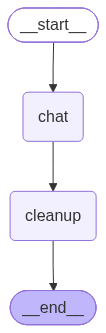

In [19]:
graph = builder.compile(checkpointer=InMemorySaver())
graph

In [20]:
config = {"configurable": {"thread_id":"t1"}}

In [22]:
graph.invoke({"messages": [{"role":"user", "content":"Hi, I'm Bhushan"}]}, config)
graph.invoke({"messages": [{"role":"user", "content":"Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role":"user", "content":"Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role":"user", "content":"What is Langchain"}]}, config)
graph.invoke({"messages": [{"role":"user", "content":"What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role":"user", "content":"What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role":"user", "content":"What is my name?"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='69678690-0c6c-4286-b433-4c99330fdeec'),
  AIMessage(content="LangChain is an open-source framework for building and deploying large-scale language models, including LangGraph. It provides a set of tools and APIs for developing, training, and deploying language models, with a focus on ease of use, scalability, and flexibility.\n\n**Key Features of LangChain**\n\n1. **Modular Architecture**: LangChain has a modular architecture that allows developers to build and deploy language models as a series of interconnected components. This makes it easy to experiment with different model architectures, training objectives, and deployment strategies.\n2. **Model Agnostic**: LangChain is model-agnostic, meaning it can be used with a wide range of language models, including transformer-based models, recurrent neural networks (RNNs), and graph-based models like LangGraph.\n3. **Scalability**: Lang